Johan Camilo Balanta Santacruz - 30000115778
Delio Fernando Palacios Viafara - 30000115782

# Modelo de Regresión mediante Redes Neuronales Convolucionales 1D (CNN 1D) para la Predicción del Volumen de Tráfico

**Dataset:** [Metro Interstate Traffic Volume](https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume)  
**Tasa de muestreo e Instancias:** 48,204 registros con de frecuencia horaria (histórico 2012–2018).  
**Objetivo del estudio:** Diseñar e instrumentar un modelo predictivo basado en Redes Neuronales Convolucionales Unidimensionales para estimar de forma continua el **volumen de tráfico** (`traffic_volume`) en la autopista I-94.

## Instalación e importaciones

In [1]:
!pip install ucimlrepo

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


## Carga del dataset

In [3]:
dataset = fetch_ucirepo(id=492)
X_raw = dataset.data.features
y_raw = dataset.data.targets


In [4]:
print("Columnas features:", X_raw.columns.tolist())
print("Columnas target: ", y_raw.columns.tolist())
print("Shape X:", X_raw.shape, "| Shape y:", y_raw.shape)
display(X_raw.head())

Columnas features: ['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time']
Columnas target:  ['traffic_volume']
Shape X: (48204, 8) | Shape y: (48204, 1)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00


## Preprocesamiento y Limpieza de Datos

1. **Integración:** Fusión de tensores de características ($X$) y variable objetivo ($y$).
2. **Descomposición Temporal:** Extracción de patrones estacionales partir del atributo `date_time` (ej. hora del día, día de la semana y mes del año).
3. **Binarización:** Discretización de características categóricas, transformando eventos festivos (`holiday`) en un flag binario (`is_holiday`).
4. **Codificación de Atributos Categóricos:** Aplicación de Transformaciones (`LabelEncoder`) sobre descripciones meteorológicas macro (`weather_main`).
5. **Reducción de Dimensionalidad:** Exclusión de columnas cualitativas redundantes para homogeneizar la topología numérica del dataset.
6. **Alineación Cronológica:** Ordenamiento estricto de los eventos para prevenir rupturas estructurales en las series de tiempo, finalizando con una depuración de posibles registros duplicados.

In [5]:
df = pd.concat([X_raw, y_raw], axis=1)

# Parsear fecha y extraer features temporales
df['date_time'] = pd.to_datetime(df['date_time'], errors='coerce')
df = df.dropna(subset=['date_time'])
df = df.sort_values('date_time').reset_index(drop=True)
df = df.drop_duplicates(subset=['date_time']).reset_index(drop=True)

df['hour']        = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['month']       = df['date_time'].dt.month

# Convertir holiday a binario
df['is_holiday'] = (df['holiday'] != 'None').astype(int)

# Codificar weather_main
le = LabelEncoder()
df['weather_code'] = le.fit_transform(df['weather_main'].astype(str))

# Eliminar columnas no numéricas
df.drop(columns=['date_time', 'holiday', 'weather_main', 'weather_description'], inplace=True)

print("Shape final:", df.shape)
print("Columnas:", df.columns.tolist())
display(df.head())

Shape final: (40575, 10)
Columnas: ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume', 'hour', 'day_of_week', 'month', 'is_holiday', 'weather_code']


,temp,rain_1h,snow_1h,clouds_all,traffic_volume,hour,day_of_week,month,is_holiday,weather_code
0,288.28,0.0,0.0,40,5545,9,1,10,1,1
1,289.36,0.0,0.0,75,4516,10,1,10,1,1
2,289.58,0.0,0.0,90,4767,11,1,10,1,1
3,290.13,0.0,0.0,90,5026,12,1,10,1,1
4,291.14,0.0,0.0,75,4918,13,1,10,1,1


In [6]:
print("Valores nulos por columna:")
print(df.isnull().sum())
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"\nShape después de limpiar: {df.shape}")

Valores nulos por columna:
temp              0
rain_1h           0
snow_1h           0
clouds_all        0
traffic_volume    0
hour              0
day_of_week       0
month             0
is_holiday        0
weather_code      0
dtype: int64

Shape después de limpiar: (40575, 10)


## Análisis Exploratorio de Datos

In [7]:
print(df.describe())

               temp       rain_1h       snow_1h    clouds_all  traffic_volume  \
count  40575.000000  40575.000000  40575.000000  40575.000000    40575.000000   
mean     281.316360      0.318606      0.000117     44.195835     3290.650474   
std       13.817015     48.812639      0.005676     38.684567     1984.772909   
min        0.000000      0.000000      0.000000      0.000000        0.000000   
25%      271.840000      0.000000      0.000000      1.000000     1248.500000   
50%      282.860000      0.000000      0.000000     40.000000     3427.000000   
75%      292.280000      0.000000      0.000000     90.000000     4952.000000   
max      310.070000   9831.300000      0.510000    100.000000     7280.000000   

               hour   day_of_week         month  is_holiday  weather_code  
count  40575.000000  40575.000000  40575.000000     40575.0  40575.000000  
mean      11.514750      3.006778      6.489045         1.0      2.103586  
std        6.949889      1.998947      3.3

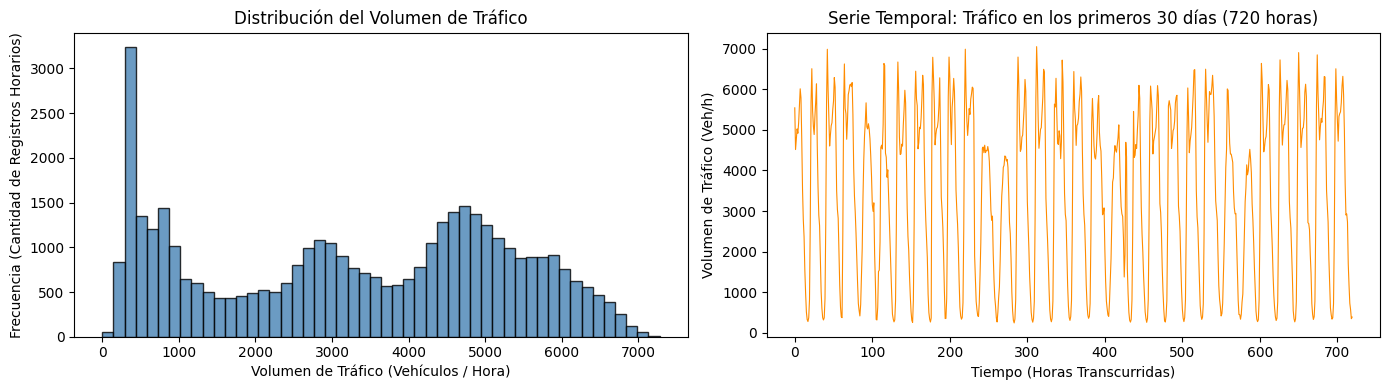

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['traffic_volume'], bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribución del Volumen de Tráfico')
axes[0].set_xlabel('Volumen de Tráfico (Vehículos / Hora)')
axes[0].set_ylabel('Frecuencia (Cantidad de Registros Horarios)')

axes[1].plot(df['traffic_volume'].values[:720], color='darkorange', linewidth=0.8)
axes[1].set_title('Serie Temporal: Tráfico en los primeros 30 días (720 horas)')
axes[1].set_xlabel('Tiempo (Horas Transcurridas)')
axes[1].set_ylabel('Volumen de Tráfico (Veh/h)')

plt.tight_layout()
plt.show()

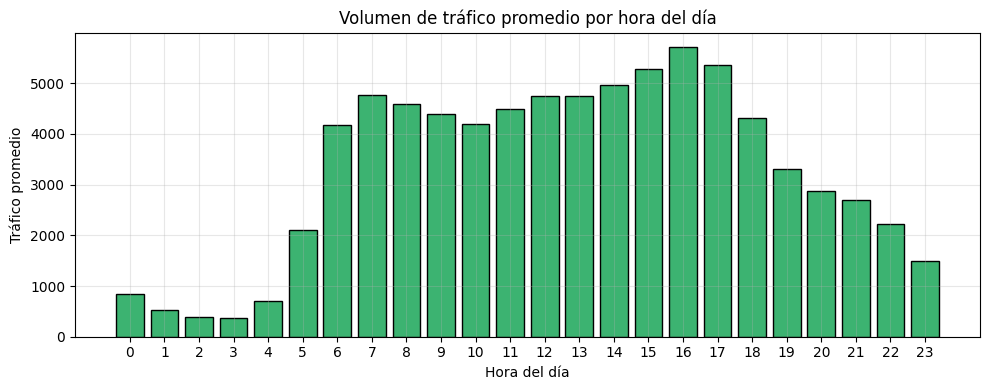

In [9]:
# Tráfico promedio por hora del día
trafico_hora = df.groupby('hour')['traffic_volume'].mean()

plt.figure(figsize=(10, 4))
plt.bar(trafico_hora.index, trafico_hora.values, color='mediumseagreen', edgecolor='black')
plt.title('Volumen de tráfico promedio por hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Tráfico promedio')
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Construcción de ventanas deslizantes

Se usan ventanas de 24 horas para predecir el volumen de la hora siguiente.

```
[t-23, t-22, ..., t-1, t]  →  predice [t+1]
```

Cada ventana es un tensor `(24, n_features)`.

In [10]:
TARGET = 'traffic_volume'
FEATURES = [c for c in df.columns if c != TARGET]
WINDOW_SIZE = 24

print(f"Features ({len(FEATURES)}): {FEATURES}")
print(f"Target: {TARGET}")
print(f"Ventana de tiempo: {WINDOW_SIZE} horas")

Features (9): ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week', 'month', 'is_holiday', 'weather_code']
Target: traffic_volume
Ventana de tiempo: 24 horas


In [11]:
# Determinar el índice de corte para entrenamiento (aprox 70%)
n_total = len(df)
i_train_split = int(n_total * 0.70)

# Estandarización 
scaler_X = StandardScaler()
scaler_y = StandardScaler()

scaler_X.fit(df[FEATURES].values[:i_train_split])
scaler_y.fit(df[[TARGET]].values[:i_train_split])

# Transformar todo el dataset usando los parámetros del conjunto de entrenamiento
X_scaled = scaler_X.transform(df[FEATURES].values)
y_scaled = scaler_y.transform(df[[TARGET]].values).flatten()

# Crear ventanas deslizantes
def crear_ventanas(X, y, window):
    X_out, y_out = [] , []
    for i in range(len(X) - window):
        X_out.append(X[i : i + window])
        y_out.append(y[i + window])
    return np.array(X_out, dtype=np.float32), np.array(y_out, dtype=np.float32)

X_win, y_win = crear_ventanas(X_scaled, y_scaled, WINDOW_SIZE)
print(f"Ventanas creadas: X={X_win.shape}  →  (muestras, window, n_features)")
print(f"Labels:           y={y_win.shape}")

Ventanas creadas: X=(40551, 24, 9)  →  (muestras, window, n_features)
Labels:           y=(40551,)


In [12]:
# División cronológica: 70% train / 15% val / 15% test
n = len(X_win)
i_train = int(n * 0.70)
i_val   = int(n * 0.85)

X_train, y_train = X_win[:i_train],       y_win[:i_train]
X_val,   y_val   = X_win[i_train:i_val],  y_win[i_train:i_val]
X_test,  y_test  = X_win[i_val:],         y_win[i_val:]

print(f"Train:      {X_train.shape[0]:,} muestras")
print(f"Validación: {X_val.shape[0]:,} muestras")
print(f"Test:       {X_test.shape[0]:,} muestras")
print(f"\nInput shape por muestra: {X_train.shape[1:]}")

Train:      28,385 muestras
Validación: 6,083 muestras
Test:       6,083 muestras

Input shape por muestra: (24, 9)


## Arquitectura del Modelo: Red Neuronal Convolucional 1D


In [24]:
def crear_modelo_cnn1d(window_size, n_features):
    model = models.Sequential([
        layers.Input(shape=(window_size, n_features)),
        
        layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),

        layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),

        layers.GlobalAveragePooling1D(),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),

        # Salida de regresión
        layers.Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.0001),
        loss='mse',
        metrics=['mae']
    )
    return model

modelo = crear_modelo_cnn1d(WINDOW_SIZE, len(FEATURES))
modelo.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 24, 64)         │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 24, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 24, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 12, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 12, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,065 (656.50 KB)

 Trainable params: 167,169 (653.00 KB)

 Non-trainable params: 896 (3.50 KB)

## Entrenamiento

In [25]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = modelo.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 1.0479 - mae: 0.8663 - val_loss: 0.8606 - val_mae: 0.8137
Epoch 2/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.7741 - mae: 0.7376 - val_loss: 0.5105 - val_mae: 0.6061
Epoch 3/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6029 - mae: 0.6312 - val_loss: 0.3338 - val_mae: 0.4616
Epoch 4/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4843 - mae: 0.5557 - val_loss: 0.2572 - val_mae: 0.3893
Epoch 5/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3958 - mae: 0.4989 - val_loss: 0.2056 - val_mae: 0.3449
Epoch 6/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3479 - mae: 0.4624 - val_loss: 0.2004 - val_mae: 0.3397
Epoch 7/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3086 - mae: 0.4319 - val_loss: 0.1708 - val_mae: 0.3141
Epoch 8/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2819 - mae: 0.4109 - val_loss: 0.1564 - val_mae: 0.3009
Epoch 9/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 4m

## Curvas de aprendizaje

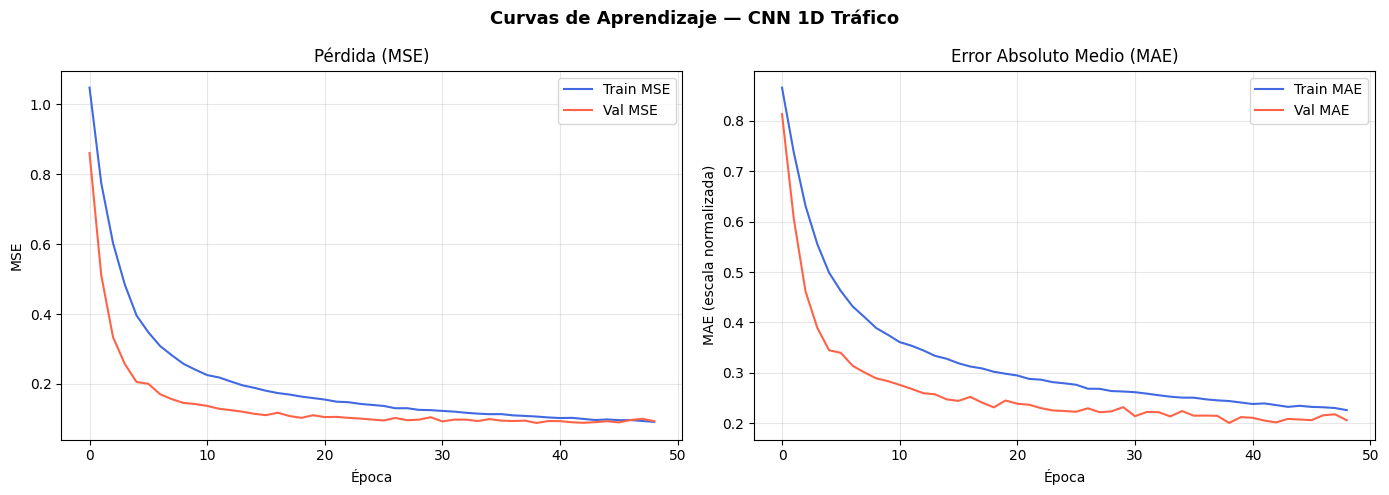

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train MSE', color='royalblue')
axes[0].plot(history.history['val_loss'], label='Val MSE',   color='tomato')
axes[0].set_title('Pérdida (MSE)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train MAE', color='royalblue')
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='tomato')
axes[1].set_title('Error Absoluto Medio (MAE)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE (escala normalizada)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizaje — CNN 1D Tráfico', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Evaluación en test

In [27]:
y_pred_scaled = modelo.predict(X_test, verbose=0).flatten()

# Desescalar a unidades originales (vehículos/hora)
y_pred_real = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test_real = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

mae  = mean_absolute_error(y_test_real, y_pred_real)
mse  = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_real, y_pred_real)

print("=" * 52)
print("   MÉTRICAS EN TEST (escala original: veh/hora)")
print("=" * 52)
print(f"  MAE  (Error Absoluto Medio):   {mae:.2f} veh/hora")
print(f"  MSE  (Error Cuadrático Medio): {mse:.2f}")
print(f"  RMSE (Raíz del MSE):           {rmse:.2f} veh/hora")
print(f"  R²   (Coef. determinación):    {r2:.4f}")
print("=" * 52)

   MÉTRICAS EN TEST (escala original: veh/hora)
  MAE  (Error Absoluto Medio):   372.77 veh/hora
  MSE  (Error Cuadrático Medio): 289038.00
  RMSE (Raíz del MSE):           537.62 veh/hora
  R²   (Coef. determinación):    0.9262


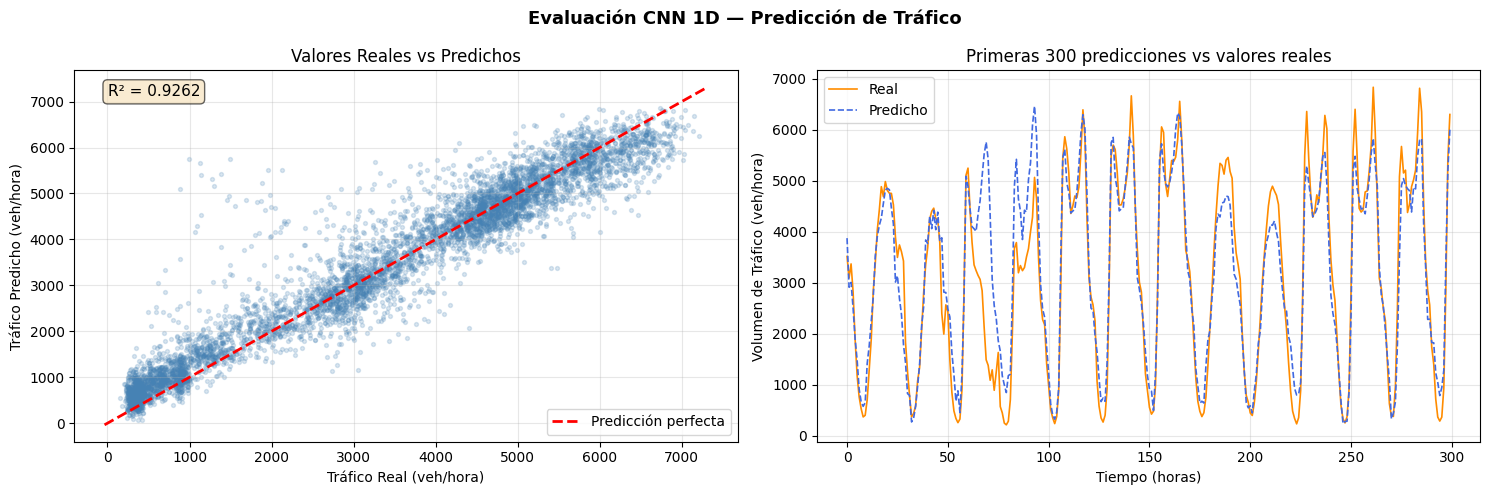

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter real vs predicho
axes[0].scatter(y_test_real, y_pred_real, alpha=0.2, color='steelblue', s=8)
lims = [min(y_test_real.min(), y_pred_real.min()) - 100,
        max(y_test_real.max(), y_pred_real.max()) + 100]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Predicción perfecta')
axes[0].set_title('Valores Reales vs Predichos')
axes[0].set_xlabel('Tráfico Real (veh/hora)')
axes[0].set_ylabel('Tráfico Predicho (veh/hora)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].text(0.05, 0.93, f'R² = {r2:.4f}', transform=axes[0].transAxes,
             fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# Serie temporal: primeras 300 predicciones
n_plot = 300
axes[1].plot(y_test_real[:n_plot], label='Real',     color='darkorange', linewidth=1.2)
axes[1].plot(y_pred_real[:n_plot], label='Predicho', color='royalblue',  linewidth=1.2, linestyle='--')
axes[1].set_title(f'Primeras {n_plot} predicciones vs valores reales')
axes[1].set_xlabel('Tiempo (horas)')
axes[1].set_ylabel('Volumen de Tráfico (veh/hora)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Evaluación CNN 1D — Predicción de Tráfico', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()